# Showcase of Girvan-Newman algorithm implementation
In the following Notebook, we showcase our implementation of the Girvan-Newman algorithm using different datasets. We will also make a performance evaluation against random graphs and make comparisons with a known library for graphs manipulation: NetworkX.
##### Authors: Kerserliss, EllynaSoumelis, Egeyae

### Imports
---

In [1]:
from girvannewman import girvannewman
from loader import load_karate, load_college_football, load_data_food_web_mat1
import matplotlib.pyplot as plt


COLORS = [
    '#1f77b4',  # Blue
    '#ff7f0e',  # Orange
    '#2ca02c',  # Green
    '#d62728',  # Red
    '#9467bd',  # Purple
    '#8c564b',  # Brown
    '#e377c2',  # Pink
    '#7f7f7f',  # Gray
    '#bcbd22',  # Yellow
    '#17becf',  # Cyan
    '#aec7e8',  # Light Blue
    '#ffbb78',  # Light Orange
    '#98df8a',  # Light Green
    '#ff9896',  # Light Red
    '#c5b0d5',  # Light Purple
    '#c49c94',  # Light Brown
    '#f7b6d2',  # Light Pink
    '#c7c7c7',  # Light Gray
    '#dbdb8d',  # Light Yellow
    '#9edae5',  # Light Cyan
]

## 1. Karate dataset
---

In the following cells, we showcase the results on the Karate dataset

[]

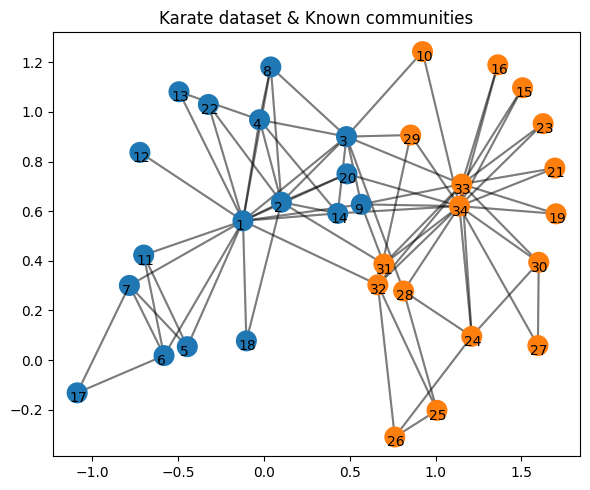

In [2]:
karate_graph, karate_known_communities = load_karate()
karate_colors = {}

for i, com in karate_known_communities.items():
    for v in com:
        karate_colors[v] = COLORS[(int(i)-1)%len(COLORS)]

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
karate_graph.plot(ax=ax, labels=True, title="Karate dataset & Known communities", colors=[karate_colors[v] for v in karate_graph.vertices])
plt.tight_layout()
plt.savefig("KnownResultsKarate.png")
plt.plot()


dict_items([('27.34', 60.91428571428571), ('19.33', 27.02222222222222), ('19.34', 38.97777777777777), ('15.33', 27.02222222222222), ('15.34', 38.97777777777777), ('21.33', 27.02222222222222), ('21.34', 38.97777777777777), ('30.33', 26.17460317460317), ('30.34', 33.44444444444444), ('16.33', 27.02222222222222), ('16.34', 38.97777777777777), ('23.33', 27.02222222222222), ('23.34', 38.977777777777774), ('24.33', 25.06666666666666), ('24.28', 11.822222222222221), ('24.34', 36.65555555555556), ('24.26', 22.188888888888886), ('26.32', 47.18888888888889), ('25.32', 45.0), ('31.9', 11.0), ('2.31', 36.21904761904762), ('34.9', 45.36984126984127), ('32.34', 59.90793650793651), ('20.34', 66.62698412698413), ('14.34', 76.09841269841267), ('28.3', 46.21746031746033), ('3.33', 77.40317460317458), ('33.9', 34.15555555555555), ('32.33', 46.48888888888888), ('29.3', 25.561904761904756), ('29.32', 16.666666666666664), ('10.3', 34.56190476190477), ('17.6', 33.0), ('17.7', 33.0), ('1.12', 66.0), ('1.14', 

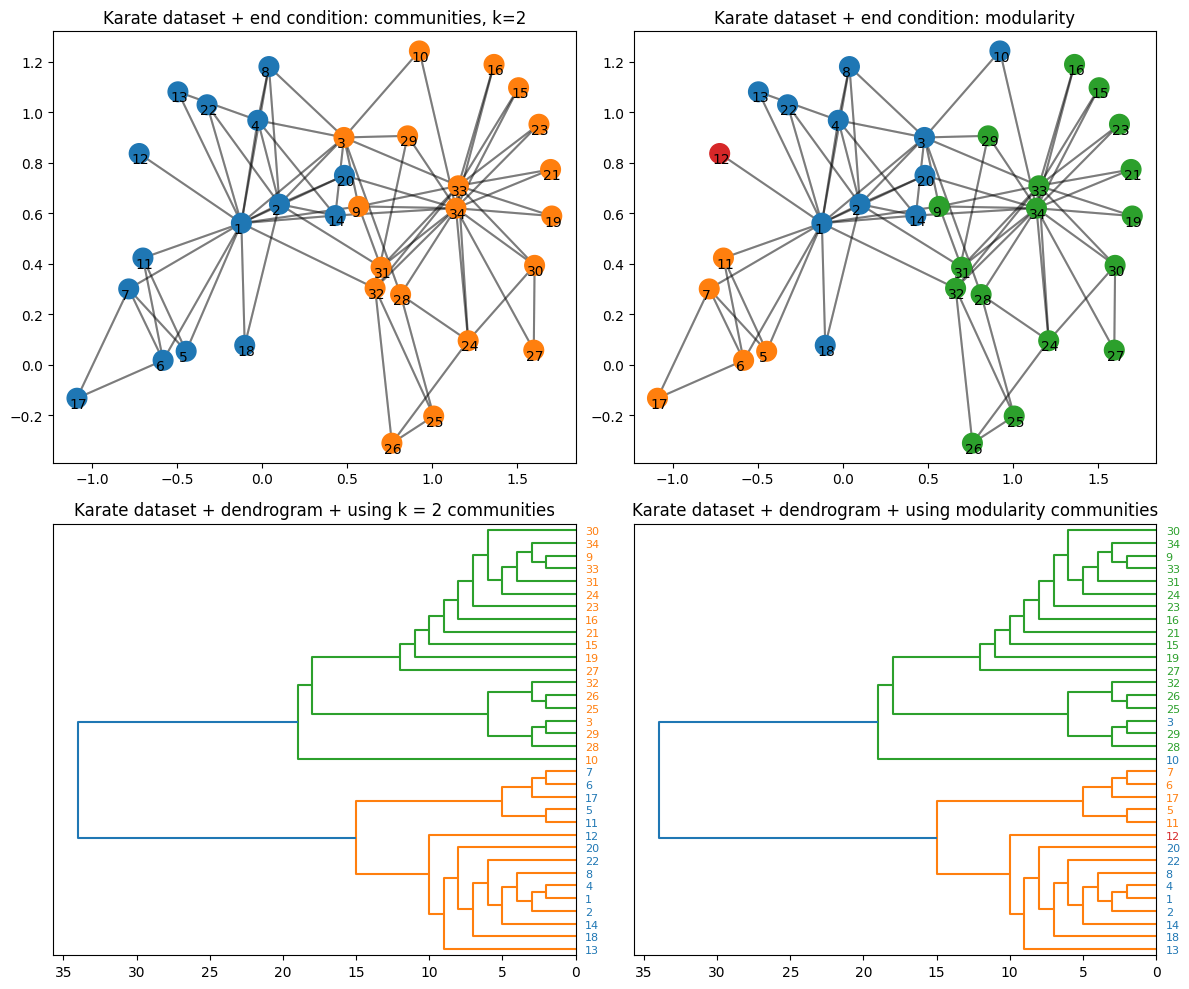

In [3]:
karate_k2_communities = girvannewman(karate_graph, method="communities", k=2)
karate_modularity_communities, _, _ = girvannewman(karate_graph, method="modularity")

k2_colors = {}
for i, com in enumerate(karate_k2_communities):
    for v in com:
        k2_colors[v] = COLORS[i%len(COLORS)]

mod_colors = {}
for i, com in enumerate(karate_modularity_communities):
    for v in com:
        mod_colors[v] = COLORS[i%len(COLORS)]
        

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
karate_graph.plot(ax=ax1, show=False, title="Karate dataset + end condition: communities, k=2", colors=[k2_colors[v] for v in karate_graph.vertices], labels=True)
karate_graph.plot(ax=ax2, show=False, title="Karate dataset + end condition: modularity", colors=[mod_colors[v] for v in karate_graph.vertices], labels=True)
girvannewman(karate_graph, method="dendrogram", title="Karate dataset + dendrogram + using k = 2 communities", label_colors=COLORS, ax=ax3, communities=karate_k2_communities)
girvannewman(karate_graph, method="dendrogram", title="Karate dataset + dendrogram + using modularity communities", label_colors=COLORS, ax=ax4, communities=karate_modularity_communities)
plt.tight_layout()
plt.savefig("ResultsKarate.png")
plt.show()

# TODO: ANALYSIS


## 2. College football
---

In the following cells, we showcase the results on the College football dataset

[]

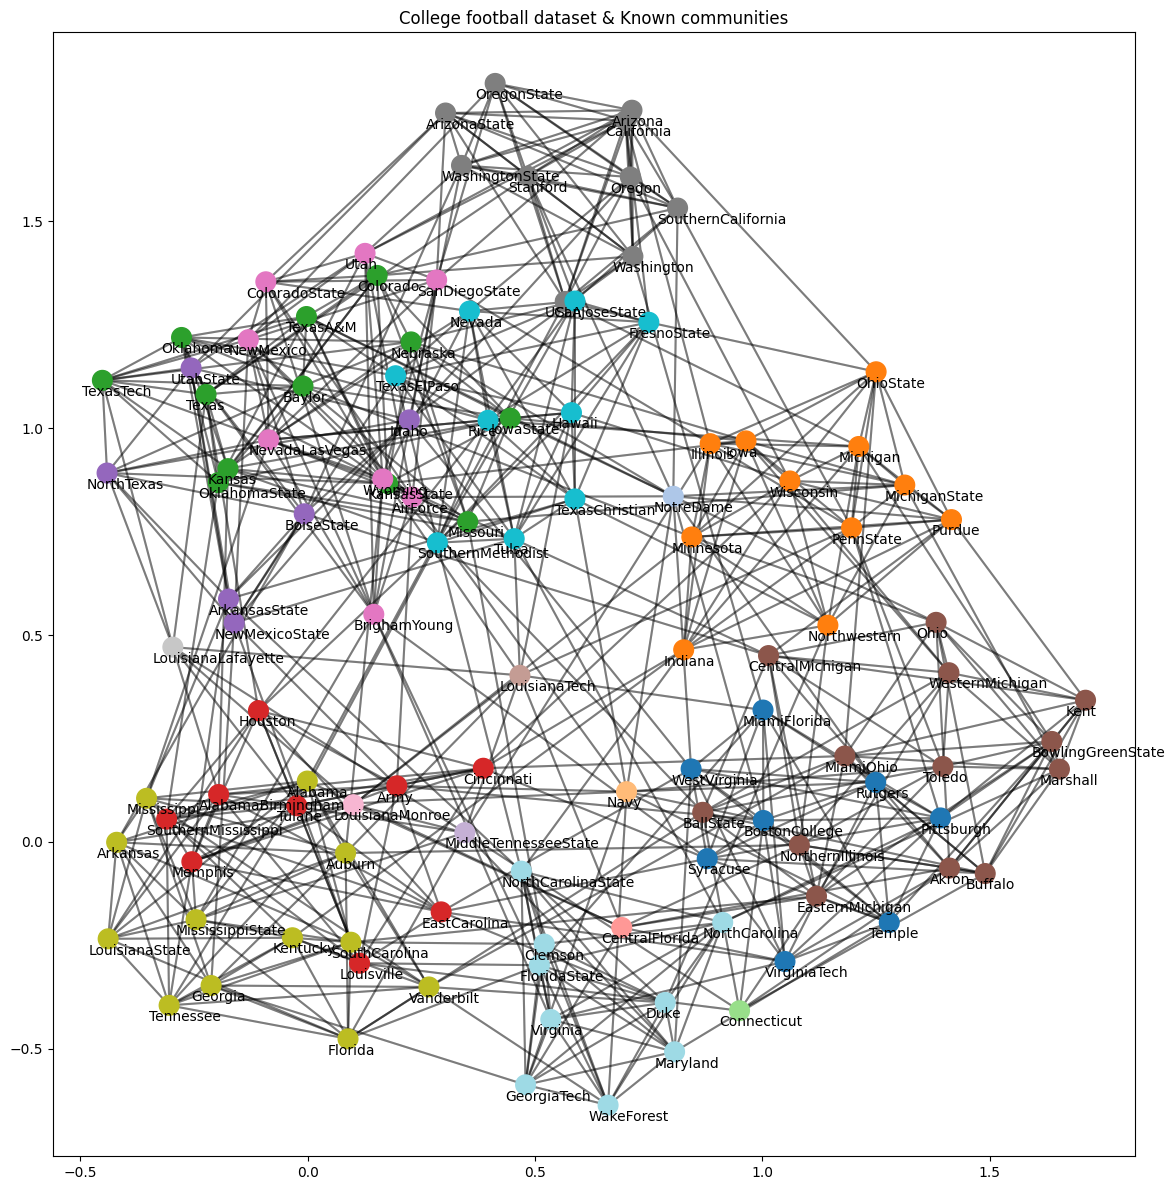

In [4]:
football_graph, football_known_communities = load_college_football()
football_colors = {}

for i, com in football_known_communities.items():
    for v in com:
        football_colors[v] = COLORS[(int(i)-1)%len(COLORS)]

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
football_graph.plot(k=500, labels=True, title="College football dataset & Known communities", colors=[football_colors[v] for v in football_graph.vertices], ax=ax, desired=0.1, repulsion=0.3, attraction=0.4)
plt.tight_layout()
plt.savefig("KnownResultsCollegeFootball.png")
plt.plot()

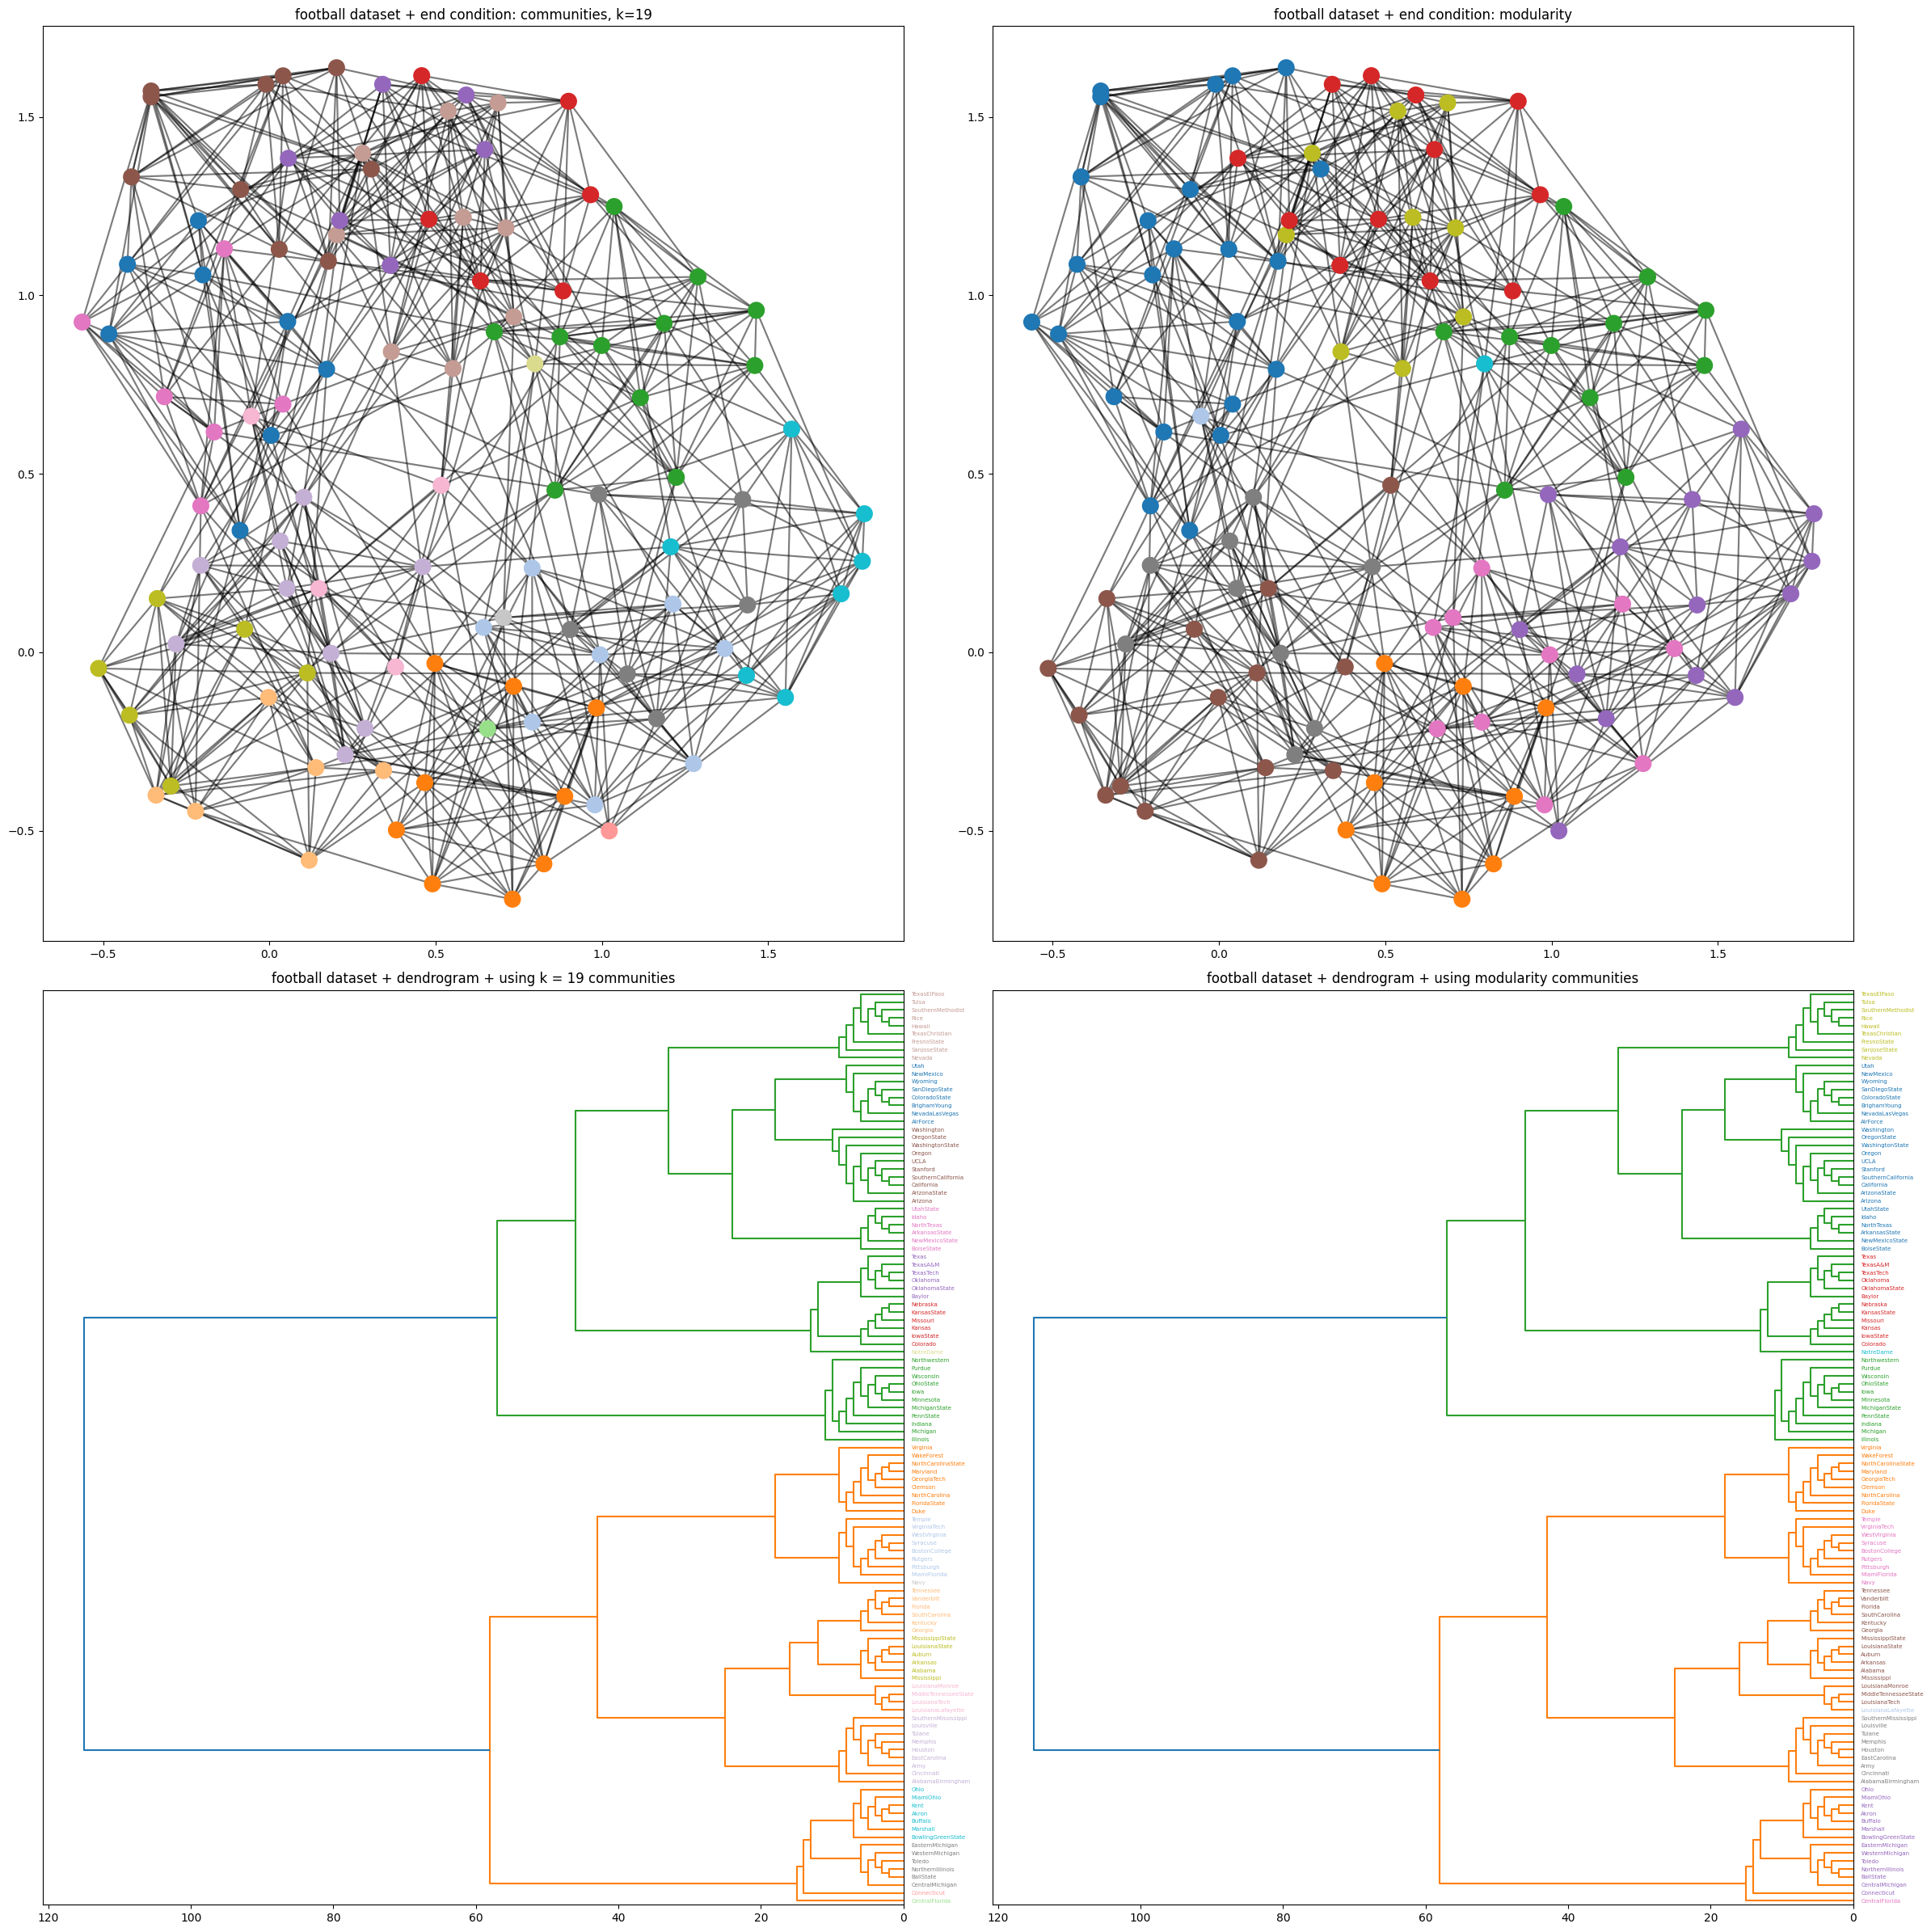

In [5]:
football_k2_communities = girvannewman(football_graph, method="communities", k=19)
football_modularity_communities, _, _ = girvannewman(football_graph, method="modularity")

k2_colors = {}
for i, com in enumerate(football_k2_communities):
    for v in com:
        k2_colors[v] = COLORS[i%len(COLORS)]

mod_colors = {}
for i, com in enumerate(football_modularity_communities):
    for v in com:
        mod_colors[v] = COLORS[i%len(COLORS)]
        

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(24, 24))
football_graph.plot(k=300, ax=ax1, show=False, title="football dataset + end condition: communities, k=19", colors=[k2_colors[v] for v in football_graph.vertices], labels=False)
football_graph.plot(k=300, ax=ax2, show=False, title="football dataset + end condition: modularity", colors=[mod_colors[v] for v in football_graph.vertices], labels=False)
girvannewman(football_graph, method="dendrogram", title="football dataset + dendrogram + using k = 19 communities", label_colors=COLORS, ax=ax3, communities=football_k2_communities)
girvannewman(football_graph, method="dendrogram", title="football dataset + dendrogram + using modularity communities", label_colors=COLORS, ax=ax4, communities=football_modularity_communities)
plt.tight_layout()
plt.savefig("ResultsCollegeFootball.png")
plt.show()

In [4]:
foodweb_mat1_graph = load_data_food_web_mat1()


foodweb_mat1_k2_communities = girvannewman(foodweb_mat1_graph, method="communities", k=2)
foodweb_mat1_modularity_communities, _, _ = girvannewman(foodweb_mat1_graph, method="modularity")

k2_colors = {}
for i, com in enumerate(foodweb_mat1_k2_communities):
    for v in com:
        k2_colors[v] = COLORS[i%len(COLORS)]

mod_colors = {}
for i, com in enumerate(foodweb_mat1_modularity_communities):
    for v in com:
        mod_colors[v] = COLORS[i%len(COLORS)]


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
foodweb_mat1_graph.plot(ax=ax1, show=False, title="foodweb_mat1 dataset + end condition: communities, k=2", colors=[k2_colors[v] for v in foodweb_mat1_graph.vertices], labels=True)
foodweb_mat1_graph.plot(ax=ax2, show=False, title="foodweb_mat1 dataset + end condition: modularity", colors=[mod_colors[v] for v in foodweb_mat1_graph.vertices], labels=True)
girvannewman(foodweb_mat1_graph, method="dendrogram", title="foodweb_mat1 dataset + dendrogram + using k = 2 communities", label_colors=COLORS, ax=ax3, communities=foodweb_mat1_k2_communities)
girvannewman(foodweb_mat1_graph, method="dendrogram", title="foodweb_mat1 dataset + dendrogram + using modularity communities", label_colors=COLORS, ax=ax4, communities=foodweb_mat1_modularity_communities)
plt.tight_layout()
plt.savefig("ResultsFoodWebMat1.png")
plt.show()

max() iterable argument is empty
dict_items([('Benthic diatoms.Hog choker', 4.564029391660972), ('Benthic diatoms.Spot', 4.230696058327638), ('Benthic diatoms.Blue Crab', 4.139786967418546), ('Benthic diatoms.Blue Fish', 5.22148033126294), ('Benthic diatoms.Striped bass', 7.199835309617921), ('Benthic diatoms.White Perch', 4.564029391660971), ('Benthic diatoms.Catfish', 4.564029391660971), ('Benthic diatoms.Other polychaetes', 4.03452380952381), ('Benthic diatoms.Sediment Bacteria', 4.03452380952381), ('Benthic diatoms.Crusta deposit feeders', 4.03452380952381), ('Benthic diatoms.Croaker', 4.564029391660973), ('Benthic diatoms.Macoma spp', 4.03452380952381), ('Benthic diatoms.Nereis', 4.03452380952381), ('Benthic diatoms.Meio Fauna', 4.03452380952381), ('Benthic diatoms.Summer Flounder', 7.123245614035086), ('Benthic diatoms.POC sediment', 4.03452380952381), ('POC sediment.Phytoplancton', 3.0523310023310017), ('POC suspended.Phytoplancton', 2.0), ('Phytoplancton.Summer Flounder', 3.956

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

